<a href="https://colab.research.google.com/github/sinsun030508/ai/blob/main/%ED%94%BC%EC%A7%80%EC%BB%AC_ai_9%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()
labels = pd.DataFrame(iris.target)
labels.columns = ['labels']
data = pd.DataFrame(iris.data)
data.columns = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width']
data = pd.concat([data, labels], axis=1)
data.head()

,Sepal length,Sepal width,Petal length,Petal width,labels
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
feature = data[['Sepal length', 'Sepal width', 'Petal length', 'Petal width']]
feature.head()

,Sepal length,Sepal width,Petal length,Petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

model = DBSCAN(eps=0.5, min_samples=5)
predict = pd.DataFrame(model.fit_predict(feature))
predict.columns = ['predict']
r = pd.concat([data, predict], axis=1)
print(r)

     Sepal length  Sepal width  Petal length  Petal width  labels  predict
0             5.1          3.5           1.4          0.2       0        0
1             4.9          3.0           1.4          0.2       0        0
2             4.7          3.2           1.3          0.2       0        0
3             4.6          3.1           1.5          0.2       0        0
4             5.0          3.6           1.4          0.2       0        0
..            ...          ...           ...          ...     ...      ...
145           6.7          3.0           5.2          2.3       2        1
146           6.3          2.5           5.0          1.9       2        1
147           6.5          3.0           5.2          2.0       2        1
148           6.2          3.4           5.4          2.3       2        1
149           5.9          3.0           5.1          1.8       2        1

[150 rows x 6 columns]


KeyError: 'precit'

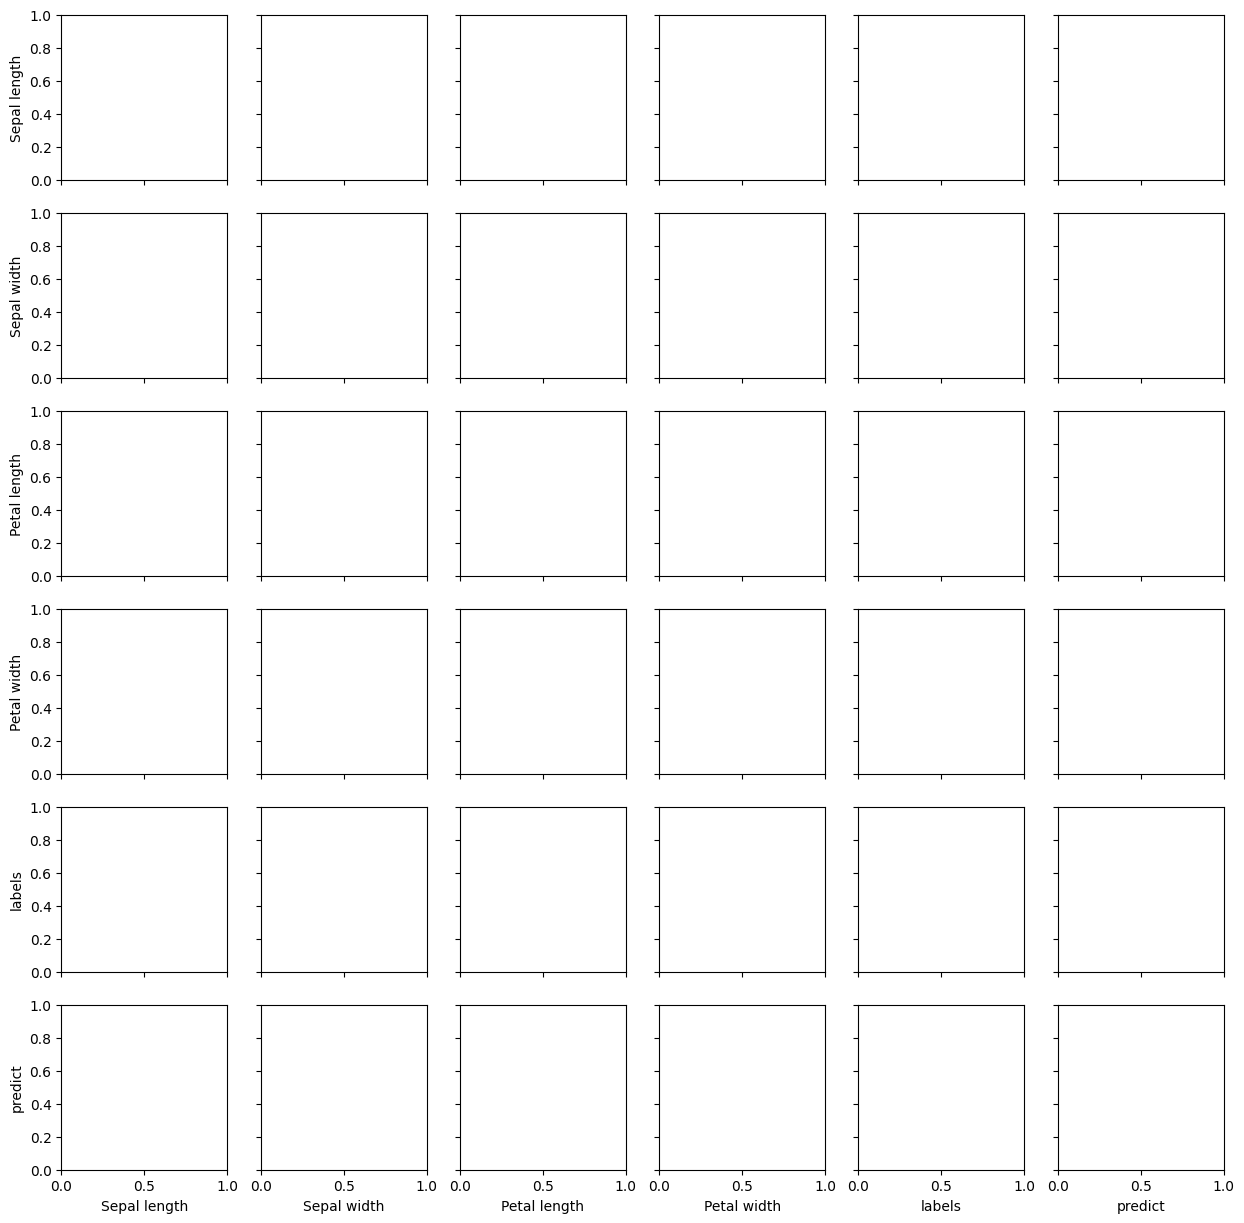

In [8]:
sns.pairplot(r, hue='precit')
plt.show()

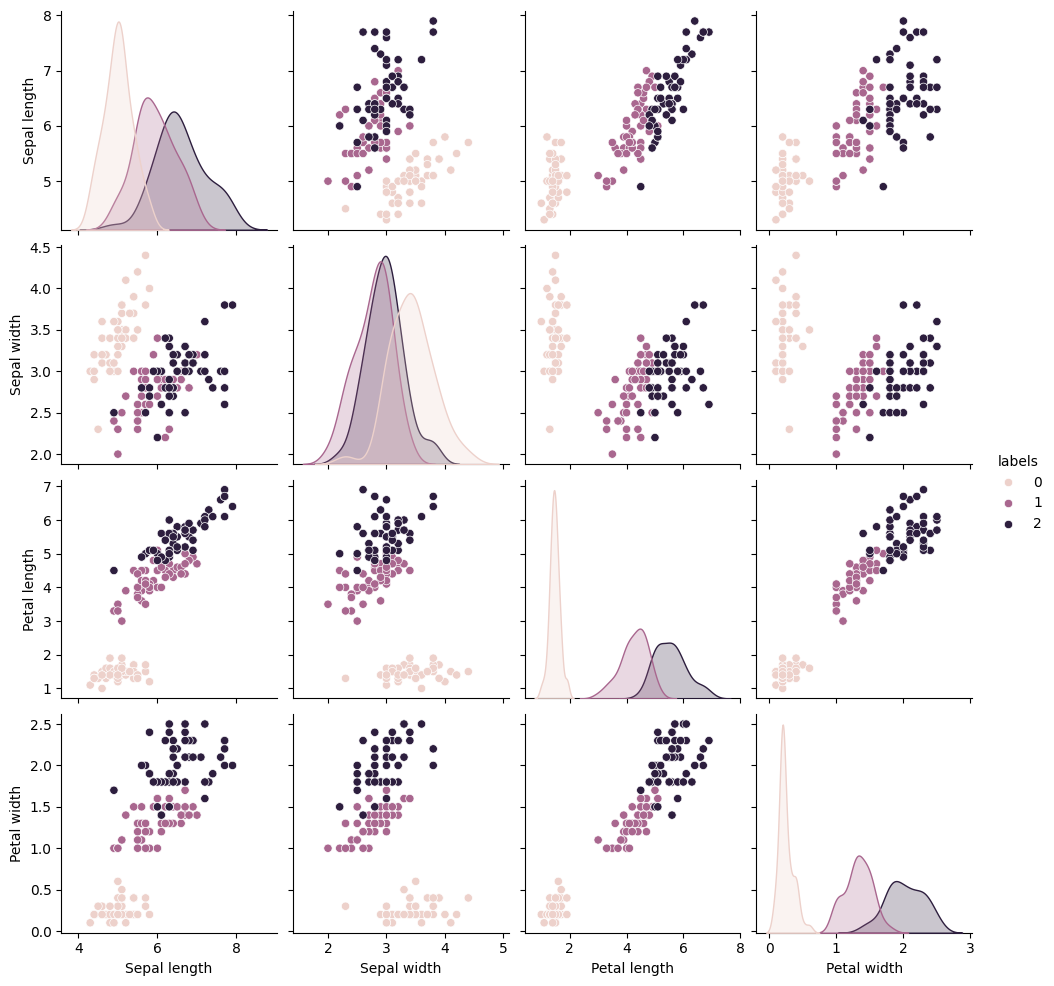

In [9]:
sns.pairplot(data,hue='labels')
plt.show()

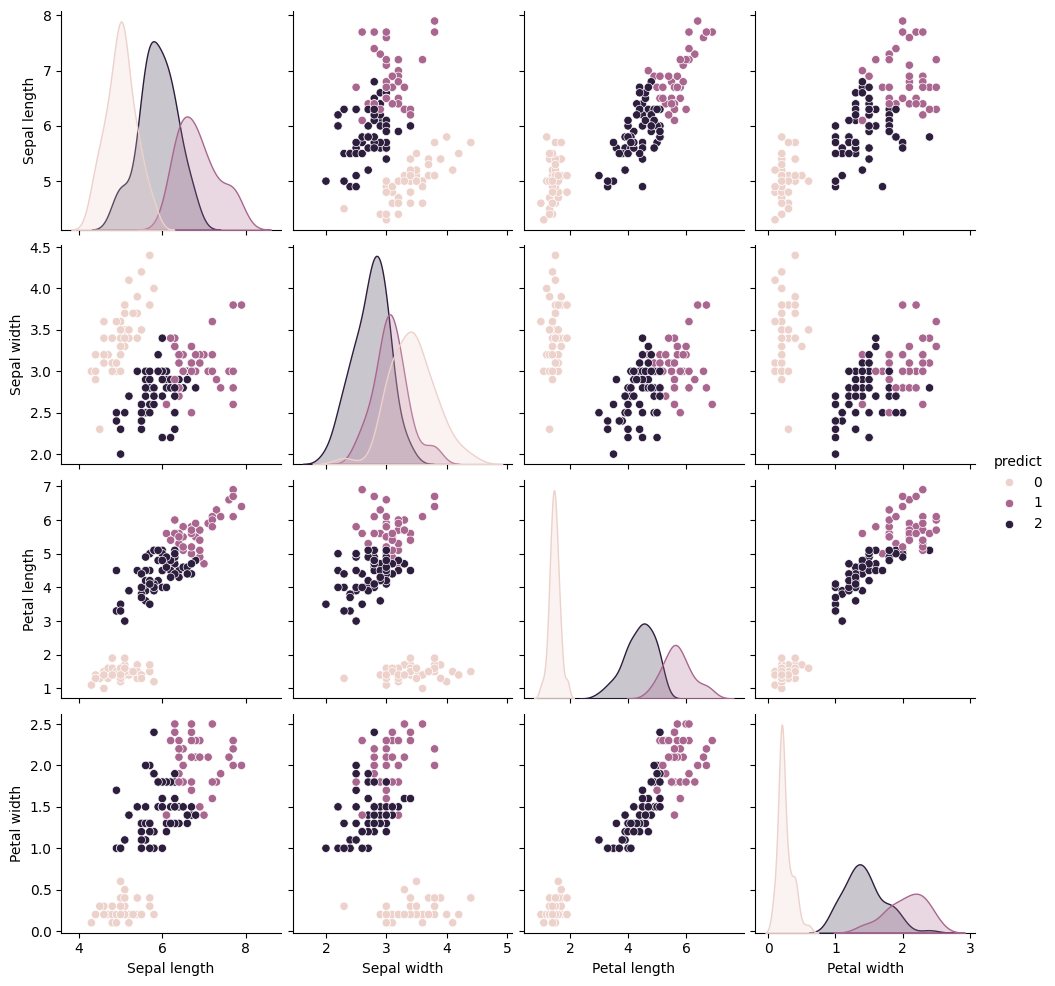

In [24]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

km = KMeans(n_clusters=3, random_state=21, n_init='auto')
km.fit(feature)
new_labels = pd.DataFrame(km.labels_)
new_labels.columns = ['predict']
r2 = pd.concat([feature, new_labels],axis=1)
sns.pairplot(r2, hue='predict')
plt.show()

<h2>GMM</h2>

In [26]:
from sklearn.datasets import load_iris

iris = load_iris()
featuer_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

iris_df = pd.DataFrame(iris.data, columns= featuer_names)
iris_df["target"] = iris.target

iris_df.head()

from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(iris_df[featuer_names])
gmm_cluster_labels = gmm.predict(iris_df[featuer_names])
iris_df['gmm_cluster'] = gmm_cluster_labels

iris_df.groupby(["target", "gmm_cluster"]).size()

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
dtype: int64

차원 축소


원래 데이터 형태 :  (150, 4)
PCA 변환 후 데이터 형태:  (150, 3)

각 주성분이 설명하는 분산 비율:
[0.72962445 0.22850762]


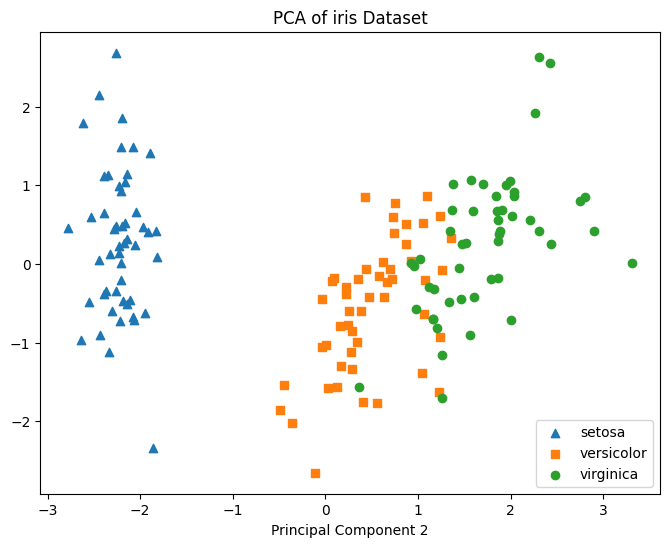

In [33]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print("원래 데이터 형태 : ", df.shape)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(df_scaled)

pac_columns = ['Component_1', 'Component_2']
df_pca = pd.DataFrame(iris_pca, columns=pac_columns)
df_pca['target'] = iris.target

print("PCA 변환 후 데이터 형태: ", df_pca.shape)
print("\n각 주성분이 설명하는 분산 비율:")
print(pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
markers = ['^', 's', 'o']

for i, marker in enumerate(markers):
  x_data = df_pca[df_pca['target'] == i] ['Component_1']
  y_data = df_pca[df_pca['target'] == i] ['Component_2']
  plt.scatter(x_data, y_data, marker=marker, label=iris.target_names[i])
plt.xlabel('Principal Component 1')
plt.xlabel('Principal Component 2')
plt.legend()
plt.title('PCA of iris Dataset')
plt.show()
